In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# **LOAD AND PREPARE DATA**

In [5]:
FILE="/content/cleaned_data.xlsx"

In [6]:
df = pd.read_excel(FILE)
df['Date']      = pd.to_datetime(df['Date'])
df['Month']     = df['Date'].dt.to_period('M').astype(str)
df['DayOfWeek'] = df['Date'].dt.day_name()
df['HasCoupon'] = df['CouponCode'].notna()

In [7]:
# ── Colour palette ─────────────────────────────────────────────────────────────
BG     = "#0a0e1a"
PANEL  = "#111827"
BORDER = "#1e2a3a"
TEXT   = "#e2e8f0"
MUTED  = "#64748b"
ACCENT = "#38bdf8"
GREEN  = "#34d399"
AMBER  = "#fbbf24"
ROSE   = "#fb7185"
PURPLE = "#a78bfa"
TEAL   = "#2dd4bf"

PRODUCT_COLORS = {
    "Chair":   "#60a5fa",
    "Desk":    "#34d399",
    "Laptop":  "#fbbf24",
    "Monitor": "#a78bfa",
    "Phone":   "#fb7185",
    "Printer": "#fb923c",
    "Tablet":  "#2dd4bf",
}
STATUS_COLORS = {
    "Delivered": "#34d399",
    "Shipped":   "#38bdf8",
    "Pending":   "#fbbf24",
    "Cancelled": "#fb7185",
    "Returned":  "#a78bfa",
}
# ── Global style ─────────────────────────────

plt.rcParams['figure.facecolor'] = BG
plt.rcParams['axes.facecolor'] = PANEL
plt.rcParams['savefig.facecolor'] = BG
plt.rcParams['text.color'] = TEXT
plt.rcParams['axes.labelcolor'] = TEXT
plt.rcParams['xtick.color'] = MUTED
plt.rcParams['ytick.color'] = MUTED
plt.rcParams['axes.edgecolor'] = BORDER
plt.rcParams['font.size'] = 12

sns.set_style("dark")

## **REVENUE BY PRODUCT**

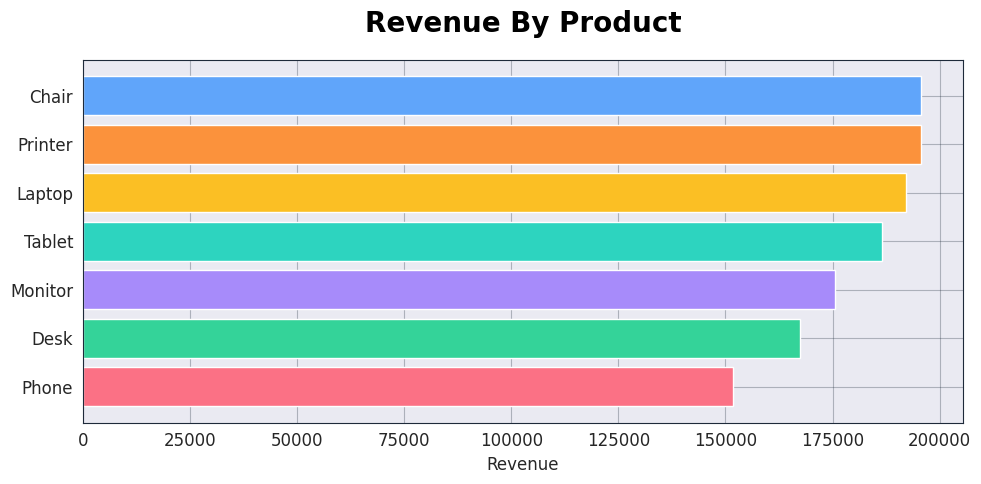

In [18]:
product_rev=(df.groupby("Product")["TotalPrice"].sum().sort_values())
colors=[PRODUCT_COLORS.get(p,"Accent") for p in product_rev.index]

fig,ax=plt.subplots(figsize=(10,5))
bars=ax.barh(product_rev.index,product_rev.values,color=colors)
ax.set_title("Revenue By Product",fontsize=20,fontweight="bold",color="black",pad=20)
ax.set_xlabel("Revenue")
ax.set_ylabel("")
ax.grid(color=BORDER,alpha=0.3)

for spine in ax.spines.values():
  spine.set_color(BORDER)

plt.tight_layout()
plt.show()

**Explanation**

This chart shows the total revenue generated by each product category.

**Key Observations**

* Chair generated the highest revenue among all products.

*   Printer and Laptop also showed strong revenue performance.

* Phone contributed the lowest overall revenue.

* Revenue distribution across products remained relatively balanced.




## **ORDER STATUS DONUT CHART**

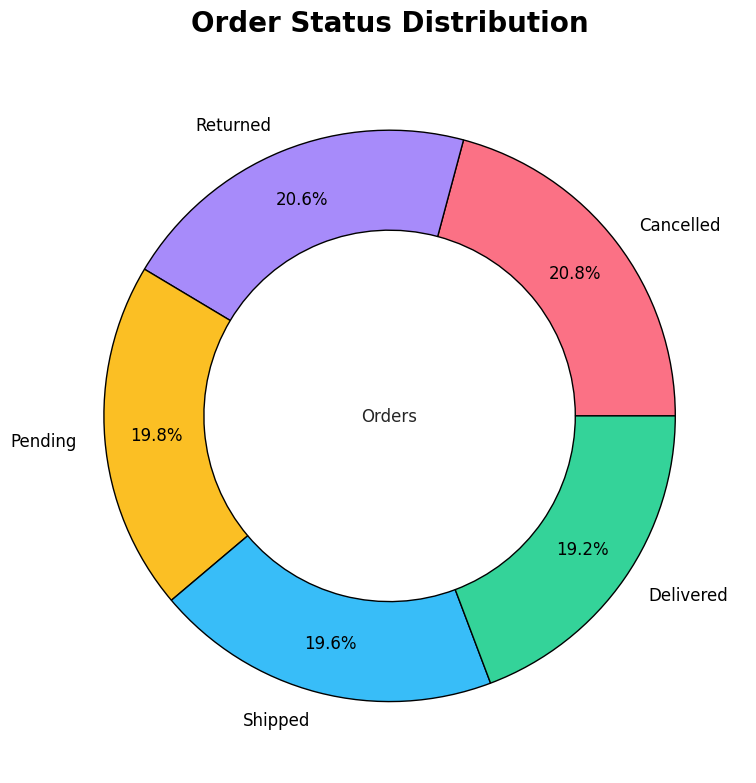

In [24]:
status_counts=df["OrderStatus"].value_counts()
colors=[STATUS_COLORS.get(status,ACCENT)for status in status_counts.index]

fig,ax=plt.subplots(figsize=(8,8))
ax.pie(status_counts,labels=status_counts.index,colors=colors,autopct="%1.1f%%",pctdistance=0.82,textprops={"color":"black"},wedgeprops=dict(width=0.35,edgecolor="black"))

ax.set_title("Order Status Distribution",fontsize=20,fontweight="bold",color="black",pad=20)
centre_circle = plt.Circle((0,0),0.55,fc="white")
fig.gca().add_artist(centre_circle)
plt.text(0,0,"Orders",ha='center',va='center')
plt.tight_layout()
plt.show()


**Explanation**

This donut chart represents the percentage distribution of different order statuses.

**Key Observations**

* Cancelled orders formed the largest proportion.

* Delivered orders accounted for a smaller percentage than expected.

* Returned and Pending orders also contributed significantly.

* Order statuses were distributed relatively evenly overall.




## **MONTHLY REVENUE TREND**

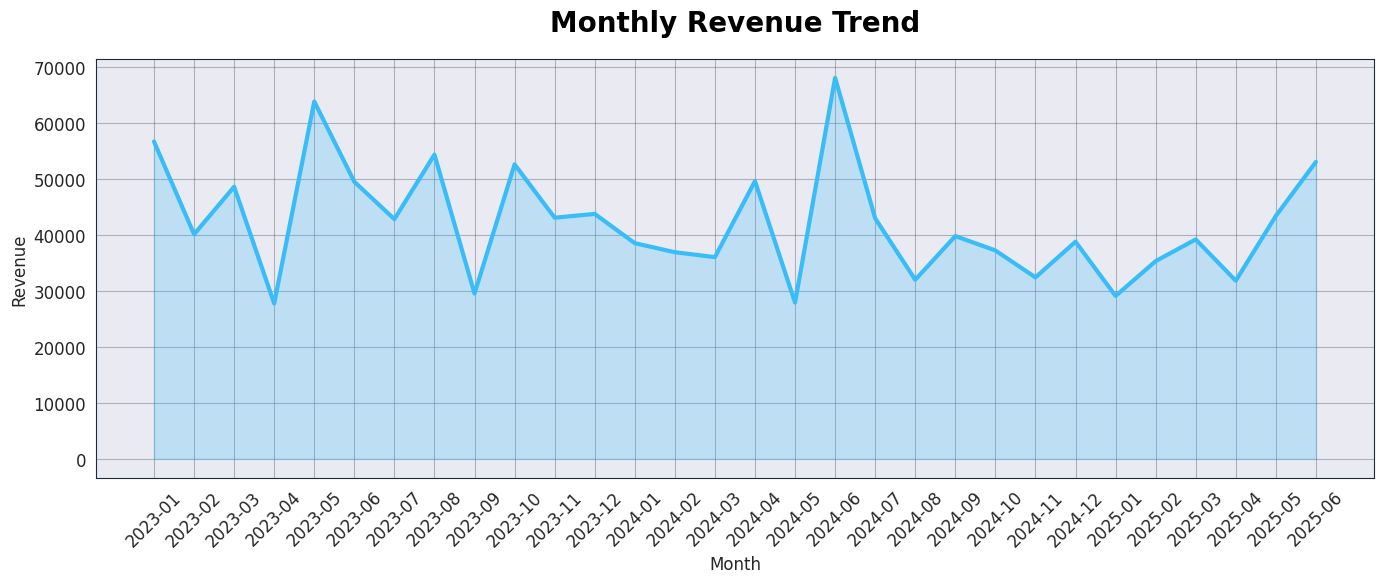

In [19]:
monthly_rev = df.groupby("Month")["TotalPrice"].sum()

fig, ax = plt.subplots(figsize=(14,6))

ax.plot(
    monthly_rev.index.astype(str),
    monthly_rev.values,
    color=ACCENT,
    linewidth=3
)

ax.fill_between(
    monthly_rev.index.astype(str),
    monthly_rev.values,
    color=ACCENT,
    alpha=0.25
)

ax.set_title(
    "Monthly Revenue Trend",
    fontsize=20,
    fontweight="bold",
    color="black",
    pad=20
)

ax.set_xlabel("Month")
ax.set_ylabel("Revenue")

ax.grid(color=BORDER, alpha=0.3)

for spine in ax.spines.values():
    spine.set_color(BORDER)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Explanation**

A line chart showing total revenue per month from January 2023 to June 2025.

**Key Observations**

*   Revenue is highly volatile month-to-month, with no clear upward or downward long-term trend.

*   The highest peaks occur around 2023-04 (~65k) and 2024-06 (~68k), suggesting possible seasonal spikes.  

*  A notable trough hits in 2024-05 (~30k), the lowest point in the entire period.

*  The most recent months (2025-04 to 2025-06) show a recovery uptick, which is encouraging.

*  Revenue generally hovers in the 30k–55k band, with outlier spikes above 60k.

## **CART SIZE vs ORDER SIZE**

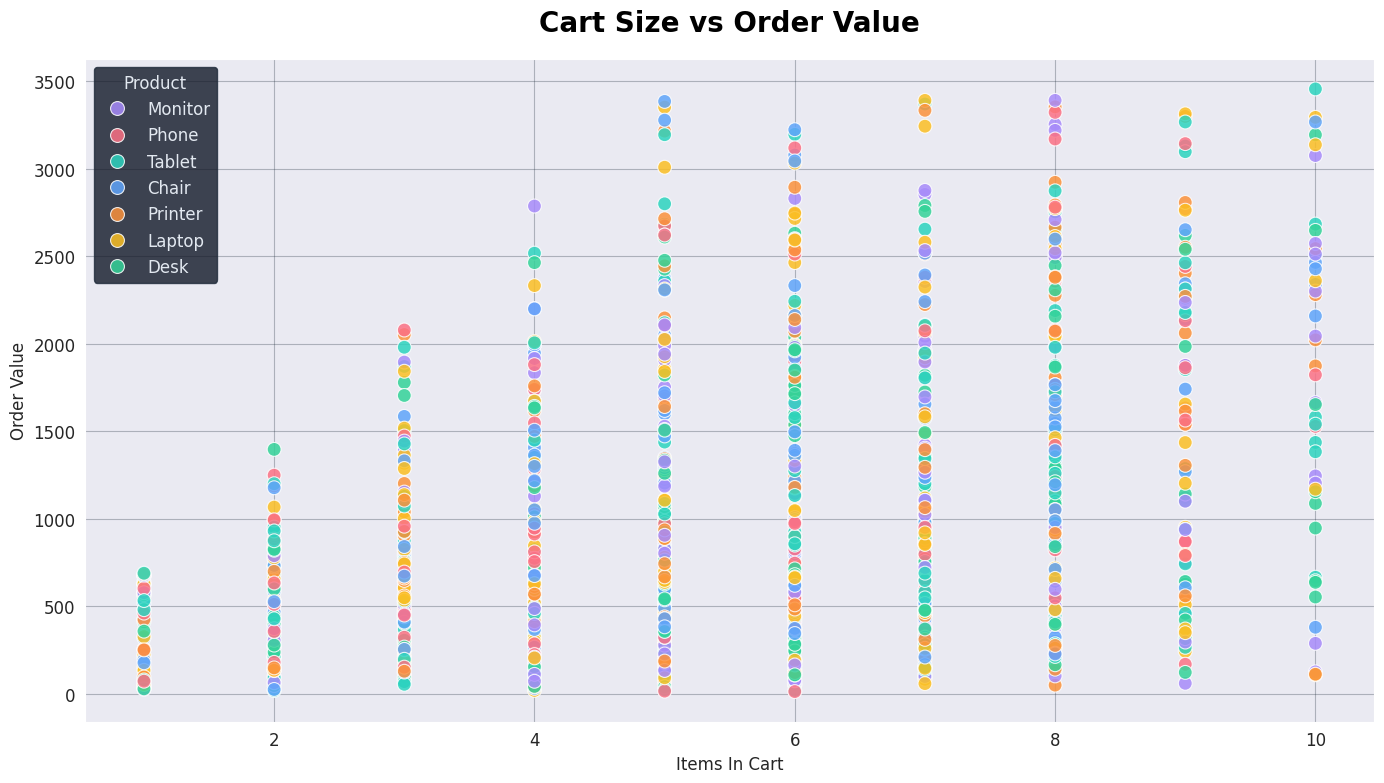

In [20]:
fig, ax = plt.subplots(figsize=(14,8))

sns.scatterplot(
    data=df,
    x="ItemsInCart",
    y="TotalPrice",
    hue="Product",
    palette=PRODUCT_COLORS,
    s=100,
    alpha=0.85,
    ax=ax
)

ax.set_title(
    "Cart Size vs Order Value",
    fontsize=20,
    fontweight="bold",
    color="black",
    pad=20
)

ax.set_xlabel("Items In Cart")
ax.set_ylabel("Order Value")

ax.grid(color=BORDER, alpha=0.3)

legend = ax.legend(
    title="Product",
    facecolor=PANEL,
    edgecolor=BORDER
)

plt.setp(legend.get_texts(), color=TEXT)
plt.setp(legend.get_title(), color=TEXT)

plt.tight_layout()
plt.show()

**Explanation**

A scatter plot showing how many items are in a cart (x-axis) vs the total order value (y-axis), colored by product type.

**Key Observations**

*  Items in cart are discrete values (1–10), creating vertical bands rather than a continuous spread.

*  Order value ranges from near 0 to ~3,500 regardless of cart size — suggesting high price variance per product.

* No strong positive correlation is visible; a cart of 2 items can yield similar order value to a cart of 8, likely because high-ticket items (Monitor, Laptop) skew value independently of quantity.

* All 7 product types appear across all cart sizes, meaning no product is exclusively bought in bulk or solo.

## **PAYMENT vs ORDER STATUS**

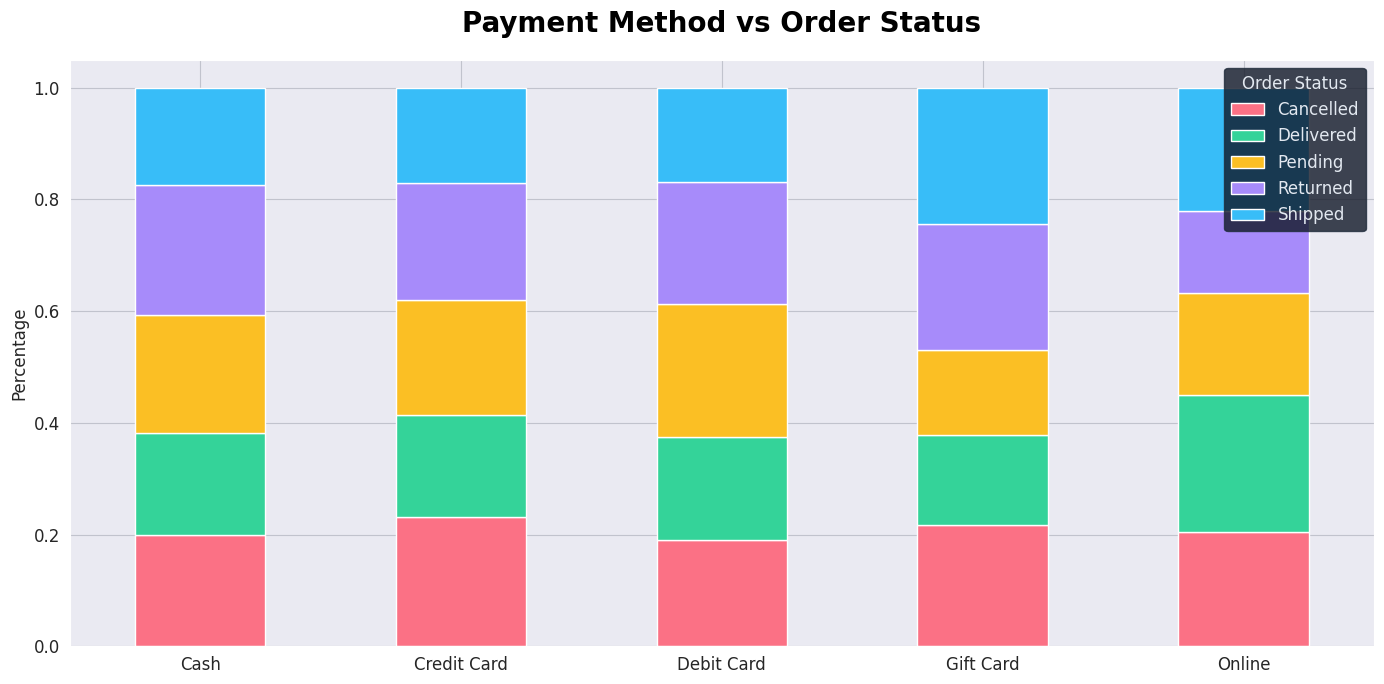

In [25]:
cross = pd.crosstab(
    df["PaymentMethod"],
    df["OrderStatus"],
    normalize="index"
)

status_palette = [
    STATUS_COLORS.get(col, ACCENT)
    for col in cross.columns
]

fig, ax = plt.subplots(figsize=(14,7))

cross.plot(
    kind="bar",
    stacked=True,
    color=status_palette,
    ax=ax
)

ax.set_title(
    "Payment Method vs Order Status",
    fontsize=20,
    fontweight="bold",
    color="black",
    pad=20
)

ax.set_ylabel("Percentage")
ax.set_xlabel("")

ax.grid(color=BORDER, alpha=0.2)

legend = ax.legend(
    title="Order Status",
    facecolor=PANEL,
    edgecolor=BORDER
)

plt.setp(legend.get_texts(), color=TEXT)
plt.setp(legend.get_title(), color=TEXT)

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

**Explanation**

A 100% stacked bar chart showing the proportion of order statuses for each payment method.

**Key Observations**

*  All 5 payment methods show a remarkably similar distribution of order statuses — no method stands out dramatically.

*  Cancelled orders (pink, ~20%) are consistently high across all payment methods, which is a concern worth investigating.

*  Shipped (blue) and Pending (orange) together make up roughly 40% across the board.

*  Debit Card appears to have a slightly larger Cancelled share compared to others.

*  The uniformity suggests payment method does not significantly influence order outcome.

## **REFERRAL SOURCE PLOT**

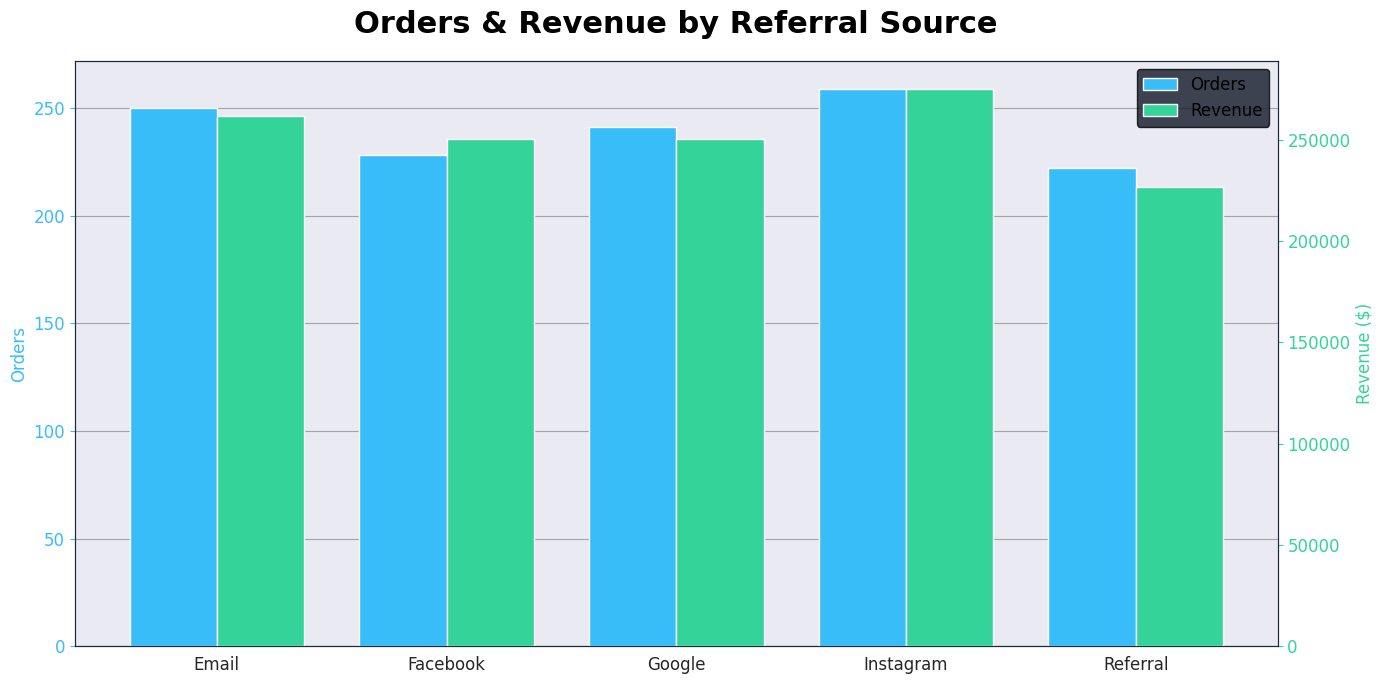

In [17]:
referral = df.groupby("ReferralSource").agg(
    Orders=("OrderID","count"),
    Revenue=("TotalPrice","sum")
)

fig, ax1 = plt.subplots(figsize=(14,7))

x = np.arange(len(referral.index))
width = 0.38

# Orders bars
bars1 = ax1.bar(
    x - width/2,
    referral["Orders"],
    width,
    label="Orders",
    color=ACCENT
)

ax1.set_ylabel("Orders", color=ACCENT)
ax1.tick_params(axis='y', colors=ACCENT)

# Revenue axis
ax2 = ax1.twinx()

bars2 = ax2.bar(
    x + width/2,
    referral["Revenue"],
    width,
    label="Revenue",
    color=GREEN
)

ax2.set_ylabel("Revenue ($)", color=GREEN)
ax2.tick_params(axis='y', colors=GREEN)

# X-axis
ax1.set_xticks(x)
ax1.set_xticklabels(referral.index)

# Styling
# fig.patch.set_facecolor(BG)
# ax1.set_facecolor(PANEL)

for spine in ax1.spines.values():
    spine.set_color(BORDER)

for spine in ax2.spines.values():
    spine.set_color(BORDER)

ax1.grid(axis='y', color="black", alpha=0.3)

plt.title(
    "Orders & Revenue by Referral Source",
    fontsize=22,
    fontweight="bold",
    color="black",
    pad=20
)

# Combined legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

legend = ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    facecolor=PANEL,
    edgecolor="black"
)

plt.setp(legend.get_texts(), color="black")

plt.tight_layout()
plt.show()

**Explanation**

A dual-axis bar chart comparing number of orders (left, blue) and revenue (right, green) across 5 referral sources.

**Key Observations**

*   Email & Instagram lead in both orders and revenue.

*  Referral is the weakest channel, with the fewest orders (~200) and lowest revenue (~190k).

*   Facebook & Google perform similarly, mid-range.

* Average order value is consistent across all channels.


